# Chapter 32 — Derivatives as Directional Information

Chapter 31 searched candidate parameters and selected the one with lowest loss.

That works for one scalar, but it cannot scale to the many parameters in a neural model.

A derivative gives local information about how changing one input changes one output.

When the input is a parameter and the output is loss, that information can guide a training update.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain a derivative as local slope and sensitivity.
2. Estimate derivatives with forward and central finite differences.
3. Compare numerical estimates with known exact derivatives.
4. Interpret positive, negative, and zero derivative signs.
5. Explain why a zero derivative does not identify a minimum by itself.
6. Draw function curves and tangent lines.
7. Explain why tangent information is local.
8. Treat loss as a function of one parameter.
9. Use a derivative sign to choose a loss-reducing direction.
10. Explain why step size affects whether an update succeeds.

## Derivatives answer a local question

A function maps an input to an output.

Its derivative at one input measures the output's local change per unit change in the input.

A positive derivative means a small move to the right raises the output, while a negative derivative means that move lowers it.

A zero derivative means the function is locally flat to first order.

The derivative is local information, not a description of the function everywhere.

## Start with the square function

The function `f(x) = x²` has exact derivative `f'(x) = 2x`.

In [1]:
def square_function(x: float) -> float:
    return x * x


def exact_square_derivative(x: float) -> float:
    return 2.0 * x


for x in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    print(f"x={x:>4.1f}  f(x)={square_function(x):>4.1f}")

x=-3.0  f(x)= 9.0
x=-2.0  f(x)= 4.0
x=-1.0  f(x)= 1.0
x= 0.0  f(x)= 0.0
x= 1.0  f(x)= 1.0
x= 2.0  f(x)= 4.0
x= 3.0  f(x)= 9.0


The function decreases as `x` moves right toward zero from the negative side and increases as `x` moves right on the positive side.

Its derivative signs capture that change in local direction.

## Estimate a derivative numerically

A forward finite difference nudges the input by a small positive amount `h`:

```text
(f(x + h) - f(x)) / h
```

A central finite difference compares equally sized nudges on both sides:

```text
(f(x + h) - f(x - h)) / (2h)
```

For smooth functions, the central estimate is usually more accurate at the same moderate `h` because its leading one-sided errors cancel.

In [2]:
from collections.abc import Callable


def forward_numerical_derivative(
    function: Callable[[float], float],
    x: float,
    small_change: float = 0.0001,
) -> float:
    if small_change <= 0:
        raise ValueError("small_change must be positive.")

    return (function(x + small_change) - function(x)) / small_change


def central_numerical_derivative(
    function: Callable[[float], float],
    x: float,
    small_change: float = 0.0001,
) -> float:
    if small_change <= 0:
        raise ValueError("small_change must be positive.")

    numerator = function(x + small_change) - function(x - small_change)

    return numerator / (2.0 * small_change)

In [3]:
x = 2.0
forward_estimate = forward_numerical_derivative(square_function, x)
central_estimate = central_numerical_derivative(square_function, x)
exact_derivative = exact_square_derivative(x)

print("x:", x)
print("Forward estimate:", forward_estimate)
print("Central estimate:", central_estimate)
print("Exact derivative:", exact_derivative)
print("Forward absolute error:", abs(forward_estimate - exact_derivative))
print("Central absolute error:", abs(central_estimate - exact_derivative))

x: 2.0
Forward estimate: 4.0001000000078335
Central estimate: 4.000000000004
Exact derivative: 4.0
Forward absolute error: 0.0001000000078335006
Central absolute error: 4.000355602329364e-12


Both estimates are close to 4, but the symmetric estimate is more accurate for this quadratic and step size.

## Compare signs at several points

The table compares the central estimate with the exact derivative `2x`.

In [4]:
points_to_check = [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]

print("    x | numerical derivative | exact derivative | local direction")
print("-" * 72)

for x in points_to_check:
    numerical = central_numerical_derivative(square_function, x)
    exact = exact_square_derivative(x)

    if exact > 0:
        direction = "increases to the right"
    elif exact < 0:
        direction = "decreases to the right"
    else:
        direction = "flat to first order"

    print(f"{x:>5.1f} | {numerical:>20.6f} | {exact:>16.6f} | {direction}")

    x | numerical derivative | exact derivative | local direction
------------------------------------------------------------------------
 -3.0 |            -6.000000 |        -6.000000 | decreases to the right
 -2.0 |            -4.000000 |        -4.000000 | decreases to the right
 -1.0 |            -2.000000 |        -2.000000 | decreases to the right
  0.0 |             0.000000 |         0.000000 | flat to first order
  1.0 |             2.000000 |         2.000000 | increases to the right
  2.0 |             4.000000 |         4.000000 | increases to the right
  3.0 |             6.000000 |         6.000000 | increases to the right


At negative `x`, moving slightly right lowers the square function.

At positive `x`, moving slightly right raises it.

At zero, the derivative is zero and this particular function has a minimum.

## Zero derivative does not always mean minimum

A zero derivative only says the function is locally flat to first order.

It could mark a minimum, a maximum, or another stationary shape.

In [5]:
def negative_square_function(x: float) -> float:
    return -(x * x)


square_derivative_at_zero = central_numerical_derivative(square_function, 0.0)
negative_square_derivative_at_zero = central_numerical_derivative(
    negative_square_function,
    0.0,
)

print("x² derivative at 0:", square_derivative_at_zero)
print("-x² derivative at 0:", negative_square_derivative_at_zero)
print("x² has a minimum there; -x² has a maximum there.")

x² derivative at 0: 0.0
-x² derivative at 0: 0.0
x² has a minimum there; -x² has a maximum there.


Additional information about nearby curvature or values is needed to classify a zero-derivative point.

## Tangent lines visualize local slope

At `current_x`, the tangent approximation is:

```text
f(current_x) + f'(current_x) × (x - current_x)
```

It matches the function value and slope at that point, but it need not match far away.

In [6]:
def tangent_line_value(
    x: float,
    current_x: float,
    current_y: float,
    slope: float,
) -> float:
    return current_y + slope * (x - current_x)

## Plot the square function and two tangents

The negative and positive slopes show opposite local directions on the two sides of the parabola.

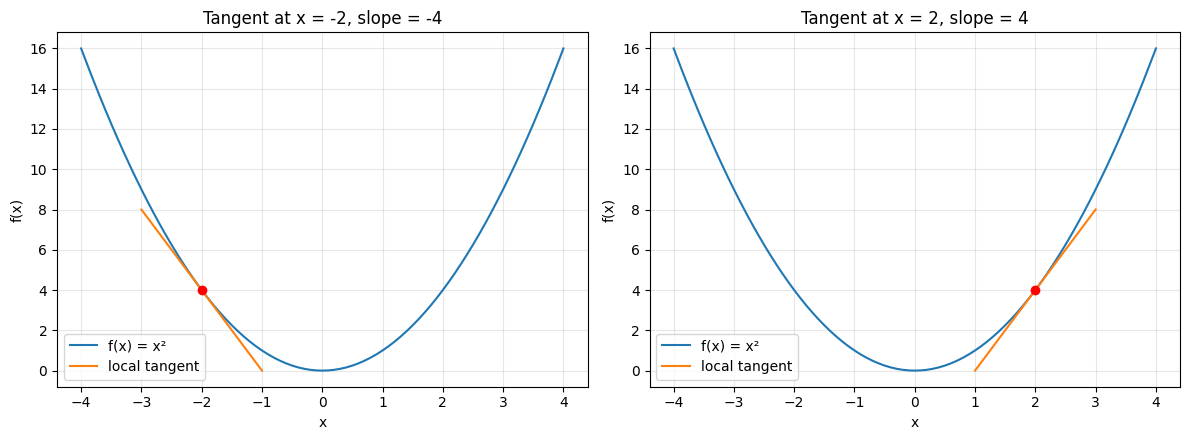

In [7]:
import matplotlib.pyplot as plt

x_values = [-4.0 + step * 0.05 for step in range(161)]
square_values = [square_function(x) for x in x_values]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for plot_axes, current_x in zip(axes, [-2.0, 2.0], strict=True):
    current_y = square_function(current_x)
    slope = exact_square_derivative(current_x)
    local_x_values = [current_x - 1.0 + step * 0.025 for step in range(81)]
    tangent_values = [
        tangent_line_value(x, current_x, current_y, slope) for x in local_x_values
    ]

    plot_axes.plot(x_values, square_values, label="f(x) = x²")
    plot_axes.plot(local_x_values, tangent_values, label="local tangent")
    plot_axes.scatter([current_x], [current_y], color="red", zorder=3)
    plot_axes.set_xlabel("x")
    plot_axes.set_ylabel("f(x)")
    plot_axes.set_title(f"Tangent at x = {current_x:.0f}, slope = {slope:.0f}")
    plot_axes.grid(True, alpha=0.3)
    plot_axes.legend()

plt.tight_layout()
plt.show()

The tangent segment agrees with the curve's immediate direction at the marked point.

Restricting the segment to a neighborhood emphasizes that this is a local approximation.

## Shift the minimum

The function `(x - 3)²` has its minimum at 3 and exact derivative `2(x - 3)`.

In [8]:
def shifted_square_function(x: float) -> float:
    return (x - 3.0) ** 2


def exact_shifted_square_derivative(x: float) -> float:
    return 2.0 * (x - 3.0)


print("    x | function | derivative | loss-reducing direction")
print("-" * 62)

for x in [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]:
    derivative = exact_shifted_square_derivative(x)

    if derivative > 0:
        reducing_direction = "left"
    elif derivative < 0:
        reducing_direction = "right"
    else:
        reducing_direction = "no first-order direction"

    print(
        f"{x:>5.1f} | {shifted_square_function(x):>8.2f} | "
        f"{derivative:>10.2f} | {reducing_direction}"
    )

    x | function | derivative | loss-reducing direction
--------------------------------------------------------------
  0.0 |     9.00 |      -6.00 | right
  1.0 |     4.00 |      -4.00 | right
  2.0 |     1.00 |      -2.00 | right
  3.0 |     0.00 |       0.00 | no first-order direction
  4.0 |     1.00 |       2.00 | left
  5.0 |     4.00 |       4.00 | left
  6.0 |     9.00 |       6.00 | left


To reduce this function near a nonzero derivative, move opposite its sign.

That rule assumes a sufficiently small move and a smooth local neighborhood.

## Treat loss as a function of weight

Return to the Chapter 31 model with input 5, target 10, and squared error.

The loss is `(5 × weight - 10)²`, whose exact derivative is `50 × weight - 100`.

In [9]:
def loss_for_weight(weight: float) -> float:
    input_number = 5.0
    target_number = 10.0
    prediction = weight * input_number

    return (prediction - target_number) ** 2


def exact_weight_loss_derivative(weight: float) -> float:
    return 50.0 * weight - 100.0

In [10]:
weights_to_check = [-1.0, 0.0, 1.0, 2.0, 3.0]

print("weight | loss   | numerical derivative | exact derivative")
print("-" * 64)

for weight in weights_to_check:
    numerical = central_numerical_derivative(loss_for_weight, weight)
    exact = exact_weight_loss_derivative(weight)
    print(
        f"{weight:>6.1f} | {loss_for_weight(weight):>6.1f} | "
        f"{numerical:>20.6f} | {exact:>16.6f}"
    )

weight | loss   | numerical derivative | exact derivative
----------------------------------------------------------------
  -1.0 |  225.0 |          -150.000000 |      -150.000000
   0.0 |  100.0 |          -100.000000 |      -100.000000
   1.0 |   25.0 |           -50.000000 |       -50.000000
   2.0 |    0.0 |             0.000000 |         0.000000
   3.0 |   25.0 |            50.000000 |        50.000000


At weight 1, the negative derivative says increasing weight locally lowers loss.

At weight 3, the positive derivative says decreasing weight locally lowers loss.

At weight 2, the zero derivative coincides with this convex curve's minimum.

## Take one derivative-guided step

For minimization, subtract a small multiple of the derivative:

```text
new_weight = current_weight - learning_rate × derivative
```

The learning rate controls step size.

In [11]:
current_weight = 1.0
learning_rate = 0.01
derivative = exact_weight_loss_derivative(current_weight)
new_weight = current_weight - learning_rate * derivative

old_loss = loss_for_weight(current_weight)
new_loss = loss_for_weight(new_weight)

print("Current weight:", current_weight)
print("Derivative:", derivative)
print("Learning rate:", learning_rate)
print("New weight:", new_weight)
print("Old loss:", old_loss)
print("New loss:", new_loss)

assert new_loss < old_loss

Current weight: 1.0
Derivative: -50.0
Learning rate: 0.01
New weight: 1.5
Old loss: 25.0
New loss: 6.25


Because the derivative was negative, subtracting it increased the weight toward 2 and reduced loss.

## Direction alone does not choose a safe step size

The derivative describes an infinitesimal local change.

A sufficiently small step often follows that guidance, while a large step can overshoot the minimum and increase loss.

In [12]:
current_weight = 1.0
current_derivative = exact_weight_loss_derivative(current_weight)

step_rows = []

for learning_rate in [0.005, 0.01, 0.04, 0.10]:
    candidate_weight = current_weight - learning_rate * current_derivative
    candidate_loss = loss_for_weight(candidate_weight)
    step_rows.append((learning_rate, candidate_weight, candidate_loss))

print("learning rate | new weight | new loss")
print("-" * 42)

for learning_rate, candidate_weight, candidate_loss in step_rows:
    print(
        f"{learning_rate:>13.3f} | {candidate_weight:>10.3f} | {candidate_loss:>8.3f}"
    )

learning rate | new weight | new loss
------------------------------------------
        0.005 |      1.250 |   14.062
        0.010 |      1.500 |    6.250
        0.040 |      3.000 |   25.000
        0.100 |      6.000 |  400.000


Learning rate 0.04 lands at weight 3 with the same loss as weight 1, while 0.10 overshoots to weight 6 and raises loss sharply.

The derivative sign was correct, but the large step traveled beyond the local neighborhood.

## Plot the loss tangent and update sizes

The left panel shows local slope at weight 1.

The right panel compares a reducing step with an overshooting step.

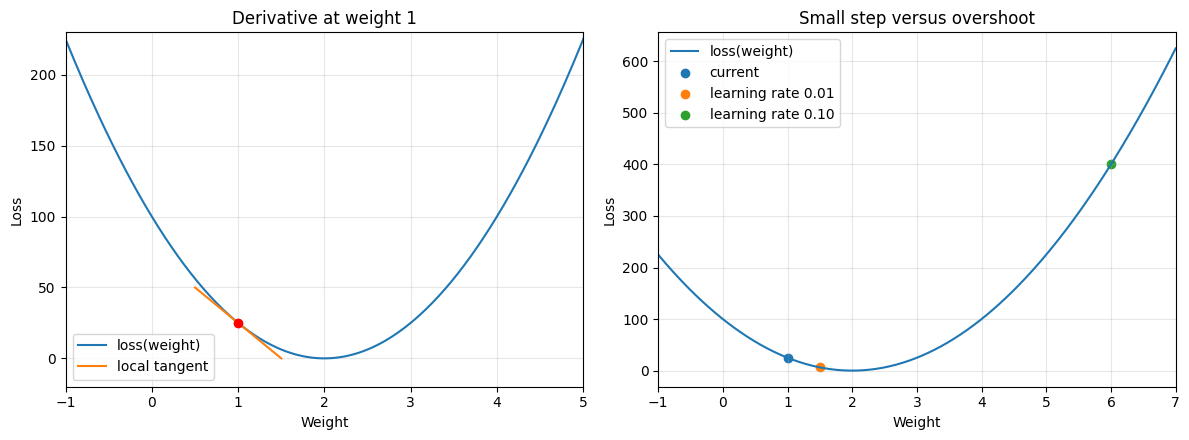

In [13]:
weight_values = [-1.0 + step * 0.025 for step in range(321)]
loss_values = [loss_for_weight(weight) for weight in weight_values]

current_weight = 1.0
current_loss = loss_for_weight(current_weight)
current_slope = exact_weight_loss_derivative(current_weight)
local_weight_values = [0.5 + step * 0.0125 for step in range(81)]
tangent_values = [
    tangent_line_value(
        weight,
        current_weight,
        current_loss,
        current_slope,
    )
    for weight in local_weight_values
]

small_step_weight = current_weight - 0.01 * current_slope
large_step_weight = current_weight - 0.10 * current_slope

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(weight_values, loss_values, label="loss(weight)")
axes[0].plot(local_weight_values, tangent_values, label="local tangent")
axes[0].scatter([current_weight], [current_loss], color="red", zorder=3)
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Loss")
axes[0].set_title("Derivative at weight 1")
axes[0].set_xlim(-1, 5)
axes[0].set_ylim(-20, 230)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(weight_values, loss_values, label="loss(weight)")
axes[1].scatter([current_weight], [current_loss], label="current")
axes[1].scatter(
    [small_step_weight],
    [loss_for_weight(small_step_weight)],
    label="learning rate 0.01",
)
axes[1].scatter(
    [large_step_weight],
    [loss_for_weight(large_step_weight)],
    label="learning rate 0.10",
)
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Loss")
axes[1].set_title("Small step versus overshoot")
axes[1].set_xlim(-1, 7)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The tangent supplies local directional information, while the learning rate determines how far the update trusts that information.

## Function value and derivative are different

The function value is the curve's height, while the derivative is its local slope.

They happen to both equal 4 for `x²` at `x = 2`, but that coincidence does not hold generally.

In [14]:
print("x | f(x) | f'(x)")
print("-" * 22)

for x in [1.0, 2.0, 3.0, 4.0]:
    print(
        f"{x:>1.0f} | {square_function(x):>4.1f} | {exact_square_derivative(x):>5.1f}"
    )

x | f(x) | f'(x)
----------------------
1 |  1.0 |   2.0
2 |  4.0 |   4.0
3 |  9.0 |   6.0
4 | 16.0 |   8.0


## Finite-difference step size is a tradeoff

Large `h` measures change over a less-local interval and introduces approximation error.

Extremely tiny `h` can lose accuracy through floating-point cancellation.

Numerical differentiation therefore needs a sensible, nonzero step size.

In [15]:
x = 2.0
exact = exact_square_derivative(x)

print("small change | forward estimate | absolute error")
print("-" * 54)

for small_change in [1.0, 0.1, 0.01, 0.0001, 1e-8, 1e-12]:
    estimate = forward_numerical_derivative(
        square_function,
        x,
        small_change,
    )
    print(
        f"{small_change:>12.1e} | {estimate:>16.10f} | {abs(estimate - exact):>14.3e}"
    )

small change | forward estimate | absolute error
------------------------------------------------------
     1.0e+00 |     5.0000000000 |      1.000e+00
     1.0e-01 |     4.1000000000 |      1.000e-01
     1.0e-02 |     4.0100000000 |      1.000e-02
     1.0e-04 |     4.0001000000 |      1.000e-04
     1.0e-08 |     3.9999999757 |      2.431e-08
     1.0e-12 |     4.0003556023 |      3.556e-04


The middle step sizes work well here, while the smallest step begins to expose finite-precision effects.

## Numerical derivatives are intuition and a checking tool

Nudging every parameter separately would require at least one extra model evaluation per parameter and would be far too slow for large networks.

Neural-network libraries use automatic differentiation to propagate derivative information efficiently through a computation.

The central question remains the same: how does changing this parameter affect loss?

## One parameter versus many parameters

This chapter uses an ordinary derivative because loss depends on one weight.

With many parameters, the corresponding collection of partial derivatives is called a gradient.

The next chapters will build that idea without changing the one-parameter intuition developed here.

## A clean derivative-guided pipeline

The final example estimates and checks a derivative, takes one small opposite-direction step, and verifies lower loss.

In [16]:
pipeline_weight = 1.0
pipeline_learning_rate = 0.01

pipeline_numerical_derivative = central_numerical_derivative(
    loss_for_weight,
    pipeline_weight,
)
pipeline_exact_derivative = exact_weight_loss_derivative(pipeline_weight)
pipeline_new_weight = (
    pipeline_weight - pipeline_learning_rate * pipeline_exact_derivative
)
pipeline_old_loss = loss_for_weight(pipeline_weight)
pipeline_new_loss = loss_for_weight(pipeline_new_weight)

print("Derivative-guided update")
print("-" * 42)
print("Current weight:", pipeline_weight)
print("Numerical derivative:", pipeline_numerical_derivative)
print("Exact derivative:", pipeline_exact_derivative)
print("New weight:", pipeline_new_weight)
print("Old loss:", pipeline_old_loss)
print("New loss:", pipeline_new_loss)

assert abs(pipeline_numerical_derivative - pipeline_exact_derivative) < 1e-8
assert pipeline_new_loss < pipeline_old_loss

Derivative-guided update
------------------------------------------
Current weight: 1.0
Numerical derivative: -49.99999999997229
Exact derivative: -50.0
New weight: 1.5
Old loss: 25.0
New loss: 6.25


## What not to do

- Do not confuse function value with derivative.
- Do not interpret a derivative as global information.
- Do not assume a zero derivative proves a minimum.
- Do not assume moving opposite the derivative helps for every step size.
- Do not use `small_change = 0` in a numerical derivative.
- Do not expect finite differences to be the main training method for large networks.

## Gotchas

A positive derivative means a small rightward move raises the function locally.

A negative derivative means a small rightward move lowers it locally.

A zero derivative means first-order flatness, which can occur at minima, maxima, or other stationary points.

Central differences often improve numerical accuracy, but finite precision still limits extremely small steps.

For loss minimization, subtracting a sufficiently small multiple of the derivative can reduce loss.

## Takeaways

A derivative measures local output change per unit input change.

Finite differences estimate derivatives by evaluating nearby function values, while exact rules provide known comparisons for simple functions.

When loss depends on one weight, the derivative indicates which nearby weight direction raises or lowers loss.

Moving opposite the derivative with a suitable step size is the core intuition behind gradient descent.

## What comes next

The next chapter introduces gradient descent.

We will repeat derivative-guided updates, track parameter and loss history, and watch a weight move toward a minimum over many steps.